In [ ]:
# import packages
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
import scipy
import psutil
import itertools
import re
import skimage

# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

import importlib

sc.set_figure_params(dpi=80)

# %load_ext line_profiler # only needed for profiling functions

In [ ]:
import cupy
import cuml
import cugraph
import cudf

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
import importlib.util
import sys

def lazy_import(
    module_name, 
    path_to_file,
):
    spec = importlib.util.spec_from_file_location(
        module_name,
        path_to_file,
    )
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
pca_utils =  lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
plotting_functions =  lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
anndata_utils =  lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
imaging_utils =  lazy_import("imaging_utils",os.path.join(utils_dir, "imaging_utils.py"))

from preprocessing_utils import kneepoint, process_pca_results, process_pca_inflection
from general_utils import ismember, write_object, read_object, flatten, grep, grep_exclude
from plotting_functions import plot_individual_category
from anndata_utils import marker_genes_for_cell_group, get_gene, filter_coordinates, query_region, random_adata_subset, zscore_with_subset
from imaging_utils import imnormalize, imblend, im2rgb, imoverlay


In [ ]:
def knn_gpu(mat, k=30):
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    return(distances, indices)

def get_cugraph_from_csr_matrix(mat):
    sources, targets = mat.nonzero()
    edges = cudf.concat([
        cudf.Series(sources, name='source'), # sources
        cudf.Series(targets, name='destination'), # targets
    ], axis=1)
    G = cugraph.from_cudf_edgelist(edges)
    return(G)

def get_cugraph_from_array(mat):
    targets = np.ravel(mat)
    n_neighbors_per_cell = [len(x) for x in mat]
    sources = np.ravel([[i]*k for i,k in zip(range(mat.shape[0]), n_neighbors_per_cell)])
    edges = cudf.concat([
        cudf.Series(sources, name='source'), # sources
        cudf.Series(targets, name='destination'), # targets
    ], axis=1)
    G = cugraph.from_cudf_edgelist(edges)
    return(G, edges)

def get_spatial_knn(adata, k = 30):
    # Compute spatial knn
    spatial_knn = knn_gpu(adata.obsm['X_spatial'])[1]
    targets = np.ravel(spatial_knn).get()
    n_neighbors_per_cell = [len(x) for x in spatial_knn]
    sources = np.ravel([[i]*k for i,k in zip(range(spatial_knn.shape[0]), n_neighbors_per_cell)])
    df = pd.DataFrame({'sources': sources, 'targets': targets})
    return(df)

from cuml.manifold import UMAP
def umap_gpu_preknn(X, knn_indices, knn_distances, n_components=2,
                    min_dist=0.1, metric = 'euclidean',random_state=0, n_epochs = 20000):
    """
    X: NumPy/CuPy (only used for shape; UMAP uses the precomputed KNN).
    knn_indices, knn_distances: CuPy int32/float32 of shape (n_samples, n_neighbors).
    """
    X_gpu = cp.asarray(X)  # ensures n_samples is known
    umap = UMAP(n_components=n_components,
                min_dist=min_dist,
                metric=metric,              # metric is ignored when precomputed_knn is used
                random_state=random_state,
                precomputed_knn=(knn_indices, knn_distances),
                n_epochs = n_epochs,verbose = True)
    embedding = umap.fit_transform(X_gpu)
    del umap
    del X_gpu
    return embedding

def compute_sample_knn(adata, slide_key, cell_type_key, selected_cell_types = [], k = 30):
    
    # Pre-compute cell_type_filter
    if(len(selected_cell_types) == 0):
        selected_cell_types = np.unique(adata.obs[cell_type_key])
    cell_type_filter = ismember(adata.obs[cell_type_key], selected_cell_types)[1]

    # Compute spatial neighborhoods per sample
    sources = np.array([], dtype=np.uint32)
    targets = np.array([], dtype=np.uint32)

    unique_slides = np.unique(adata.obs[slide_key])
    for my_slide in tqdm(unique_slides):
        slide_filter = adata.obs[slide_key] == my_slide
        selected_cell_indexes_slide = np.where(slide_filter)[0]
        adata_sub = adata[slide_filter,:].copy()
        
        selected_cells = np.logical_and(slide_filter, cell_type_filter)
        selected_cell_indexes_query = np.where(selected_cells)[0]
        
        result = get_spatial_knn(adata_sub, k=k)        
        sources = np.hstack((sources, selected_cell_indexes_slide[result['sources'].to_numpy().astype(np.uint32)]))
        targets = np.hstack((targets, selected_cell_indexes_slide[result['targets'].to_numpy().astype(np.uint32)]))
        
    spatial_neighborhood = scipy.sparse.csr_matrix(([1] * len(sources), (sources, targets)), shape = [adata.n_obs] * 2).astype(np.uint8)
    return(spatial_neighborhood)

def phenograph_gpu(indices, resolution = 1.0):
    G, edges = get_cugraph_from_array(indices)
    jaccard_edges = cugraph.jaccard(G, edges[['source', 'destination']])
    G_jaccard = cugraph.from_cudf_edgelist(jaccard_edges, *jaccard_edges.columns)
    resolution = resolution
    result, score = cugraph.leiden(G, resolution = resolution)
    # Sort clusters by size
    min_size = 0
    sizes = result['partition'].value_counts()
    sizes.loc[:] = cp.where(sizes > min_size, cp.arange(len(sizes)), -1)
    result['partition'] = result['partition'].map(sizes)
    # Sort by vertex (e.g. cell)
    clusters = result.sort_values('vertex')['partition'].values.get()
    return(clusters)

In [ ]:
import matplotlib.patches as patches
from shapely import Polygon, Point, affinity, intersection, MultiPolygon
from geopandas.geodataframe import GeoDataFrame
import geopandas as gpd

def mask_to_shapely_polygons(binary_mask):
    """
    Converts a binary mask (NumPy array) into a Shapely Polygon object.

    Args:
        binary_mask (np.ndarray): A 2D NumPy array representing the binary mask,
                                   where non-zero values indicate the object.

    Returns:
        geopandas.geodataframe.GeoDataFrame: A GeoDataFrame with shapely polygons as geometry
    """
    mask_uint8 = binary_mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None  # No contours found

    polygons = []
    for contour in contours:
        if contour.shape[0] >= 3:  # A polygon needs at least 3 points
            # Reshape contour to (N, 2) for Shapely Polygon
            coords = contour.squeeze().tolist()
            polygon = Polygon(coords)
            polygons.append(polygon)
    gdf = gpd.GeoDataFrame(geometry=polygons)
    return gdf

In [ ]:
def attach_signature(adata, signature_genes, signature_name, layer = 'X'):
    if layer == "X":
        mat = adata[:,ismember(adata.var_names, signature_genes)[1]].X
    else:
        mat = adata[:,ismember(adata.var_names, signature_genes)[1]].layers[layer]
    signature = np.ravel(mat.mean(axis=1))
    adata.obs[signature_name] = signature

In [ ]:
adata = sc.read_h5ad("../preprocessed/Reyes_COMET_Krasi4h_adata_04_all_samples.h5ad")

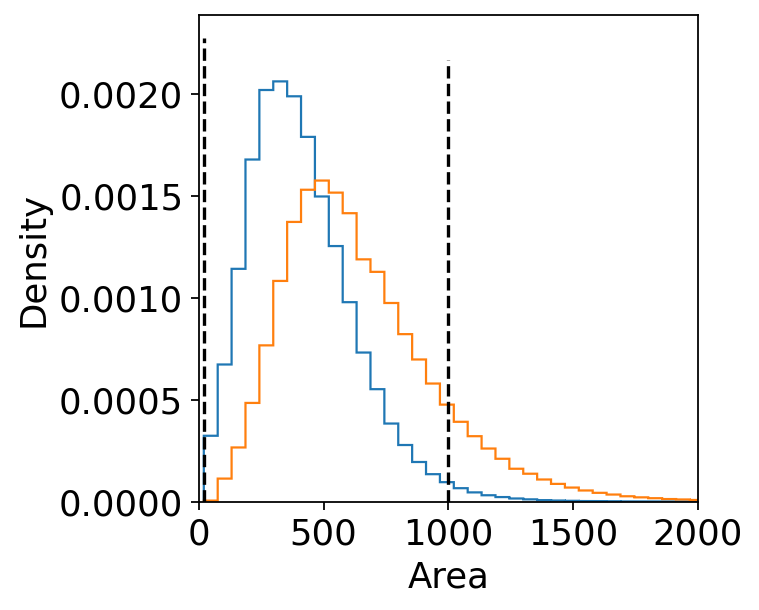

In [ ]:
h1, bins = np.histogram(adata.obs['nucleus_area'].to_numpy(), bins = 1500, density = True)
h2, _ = np.histogram(adata.obs['cyto_area'].to_numpy(), bins = bins, density = True)
plt.stairs(h1, bins)
plt.stairs(h2, bins)
threshold_max = 1000
threshold_min = 20
plt.plot([threshold_max]*2, plt.gca().get_ylim(), 'k--')
plt.plot([threshold_min]*2, plt.gca().get_ylim(), 'k--')
plt.xlim([0,2000])
plt.xlabel("Area")
plt.ylabel("Density")

area_filter = np.logical_and(adata.obs['nucleus_area'].to_numpy() < threshold_max, adata.obs['nucleus_area'].to_numpy() > threshold_min)

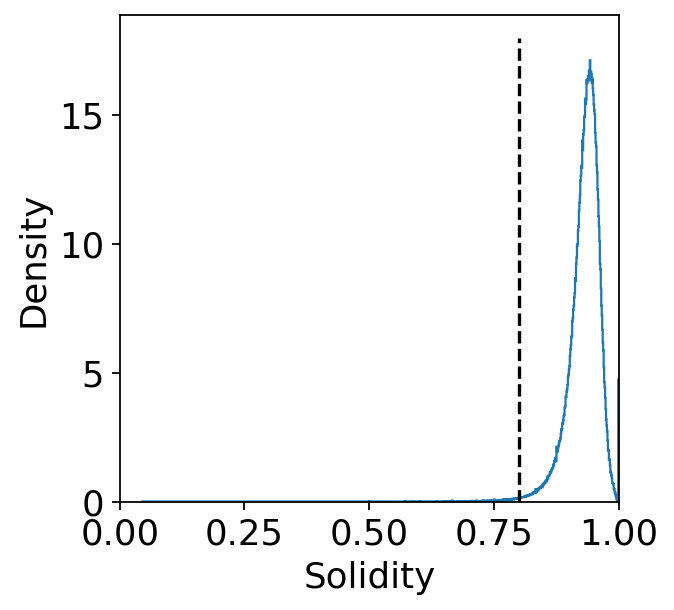

In [ ]:
h1, bins = np.histogram(adata.obs['nucleus_solidity'].to_numpy(), bins = 1000, density = True)
plt.stairs(h1, bins)
threshold = 0.8
plt.plot([threshold]*2, plt.gca().get_ylim(), 'k--')
plt.xlim([0,1])
plt.xlabel("Solidity")
plt.ylabel("Density")

solidity_filter = adata.obs['nucleus_solidity'].to_numpy() > threshold

In [ ]:
valid_cells = np.logical_and(area_filter, solidity_filter)
print("Keeping " + str(np.sum(valid_cells)) + " out of " + str(len(valid_cells)))

Keeping 2211109 out of 2257041


In [ ]:
adata.layers['raw'] = adata.X.copy()

Prepare manual mask files

In [ ]:
mask_path = "../manual_masks/"
possible_masks = np.sort(os.listdir(mask_path))


Define feature set

In [ ]:
valid_markers = [
    'DAPI_nucleus_mean_intensity', 'dpERK_cyto_mean_intensity','dpERK_nucleus_mean_intensity', 'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity','LGALS4_nucleus_mean_intensity','E-cadherin_cyto_mean_intensity', 'GFP_cyto_mean_intensity',
    'GFP_nucleus_mean_intensity','ANXA10_cyto_mean_intensity','ANXA10_nucleus_mean_intensity','VIM_cyto_mean_intensity',
    'VIM_nucleus_mean_intensity','p19_nucleus_intensity_ratio', 'p19_nucleus_mean_intensity', 'CC3_cyto_mean_intensity',
    'CC3_nucleus_mean_intensity', 'CPA1_nucleus_mean_intensity', 'CPA1_cyto_mean_intensity']

valid_markers_reduced = [
    'DAPI_nucleus_mean_intensity', 'dpERK_nucleus_mean_intensity', 'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity', 'GFP_cyto_mean_intensity','ANXA10_nucleus_mean_intensity','VIM_cyto_mean_intensity',
    'p19_nucleus_intensity_ratio','CPA1_nucleus_mean_intensity']

In [ ]:
possible_masks

array(['20251125_123820_1_Hq4Dco_JR_NP_Revision_C_JR-sp-15-010_BackgroundSub.ome-labels.ome.tif',
       '20251125_123820_1_Hq4Dco_JR_NP_Revision_C_JR-sp-15-010_BackgroundSub.ome-labels_excluded.ome.tif',
       '20251125_123821_2_KQTdWY_JR_NP_Revision_C_JR-sp-15-011_BackgroundSub.ome-labels.ome.tif',
       '20251125_123821_2_KQTdWY_JR_NP_Revision_C_JR-sp-15-011_BackgroundSub.ome-labels_excluded.ome.tif',
       '20251126_131206_1_R0D41L_JR_NP_Revision_C_JR-sp-40-13_backgroundSub.ome-labels.ome.tif',
       '20251126_131206_1_R0D41L_JR_NP_Revision_C_JR-sp-40-13_backgroundSub.ome-labels_excluded.ome.tif',
       '20251126_131206_2_1tJiNx_JR_NP_Revision_C_JR-sp-40-11_BackgroundSub.ome-labels.ome.tif',
       '20251126_131206_2_1tJiNx_JR_NP_Revision_C_JR-sp-40-11_BackgroundSub.ome-labels_excluded.ome.tif',
       '20251126_131206_3_XB0vpq_JR_NP_Revision_C_JP-sp-40-17_BackgroundSub.ome-labels.ome.tif',
       '20251126_131206_3_XB0vpq_JR_NP_Revision_C_JP-sp-40-17_BackgroundSub.ome-labels_

### Analyze single slide

In [ ]:
selected_slide = "JR-sp-15-011"
slide_filter = adata.obs['slide_id'] == selected_slide
cell_filter = np.logical_and(slide_filter, valid_cells)

adata_sub = adata[cell_filter,:].copy()

Import manually annotated masks and annotate cells

In [ ]:
progenitor_mask_file = grep("labels.ome", grep(selected_slide, possible_masks))[0]
excluded_mask_file = grep("excluded.ome", grep(selected_slide, possible_masks))[0]
progenitor_mask = skimage.io.imread(os.path.join(mask_path, progenitor_mask_file))
excluded_mask = skimage.io.imread(os.path.join(mask_path, excluded_mask_file))

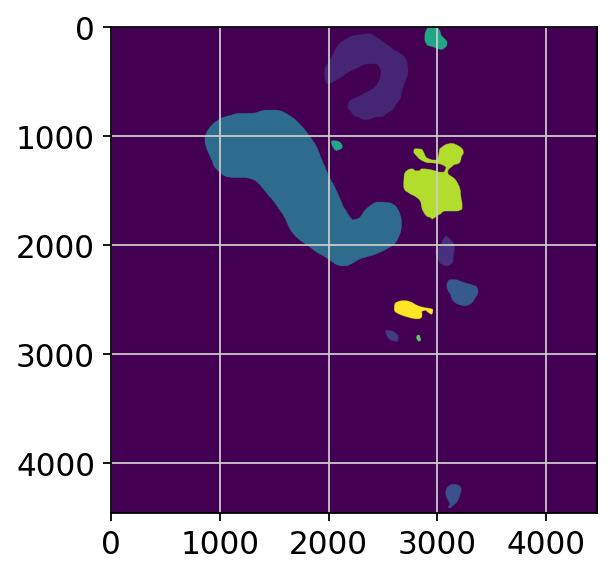

In [ ]:
if selected_slide.startswith("JR-sp-15"):
    excluded_mask_new = np.multiply(excluded_mask, np.logical_not(progenitor_mask>0).astype(np.uint8))
    plt.imshow(cv2.resize(excluded_mask_new, None, fx = 0.1, fy = 0.1, interpolation = cv2.INTER_LINEAR))
    excluded_mask = excluded_mask_new

In [ ]:
progenitor_mask_polygons = mask_to_shapely_polygons(progenitor_mask)
excluded_mask_polygons = mask_to_shapely_polygons(excluded_mask)

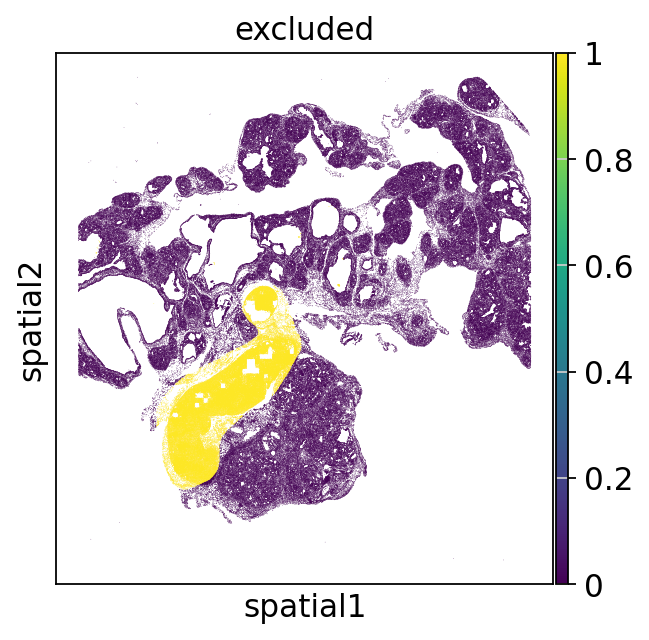

In [ ]:
gdf = gpd.GeoDataFrame(geometry = [Point(x,y) for x,y in zip(adata_sub.obsm['X_spatial'][:,1], adata_sub.obsm['X_spatial'][:,0])])
joined = gdf.sjoin(excluded_mask_polygons)
adata_sub.obs['excluded'] = ismember(list(range(adata_sub.n_obs)), joined.index.to_numpy())[1]
sc.pl.scatter(adata_sub, color = 'excluded', basis='spatial')

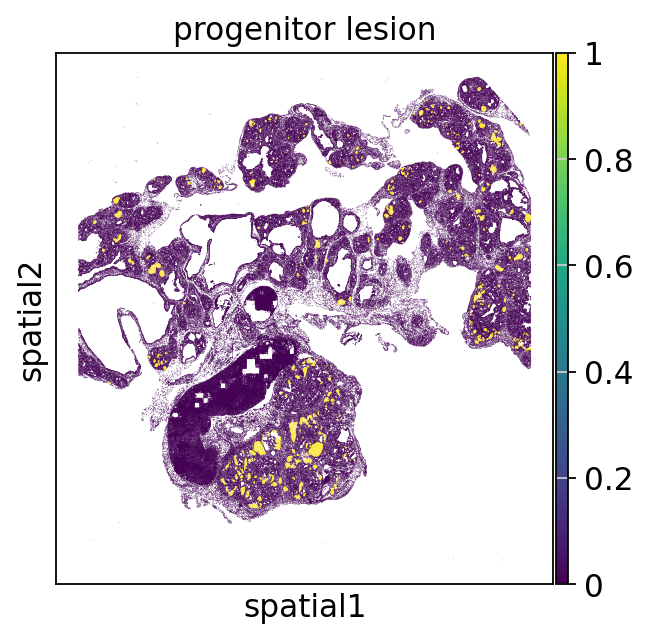

In [ ]:
joined = gdf.sjoin(progenitor_mask_polygons)
adata_sub.obs['progenitor_lesion'] = ismember(list(range(adata_sub.n_obs)), joined.index.to_numpy())[1]
sc.pl.scatter(adata_sub, color = 'progenitor_lesion', basis='spatial')

In [ ]:
adata_sub = adata_sub[adata_sub.obs['excluded'] == False,:].copy()

In [ ]:
adata_sub.X = adata_sub.layers['raw'].copy()
sc.pp.log1p(adata_sub)
sc.pp.scale(adata_sub)

adata_sub.var['valid_markers'] = ismember(adata_sub.var_names, valid_markers)[1]

sc.pp.pca(adata_sub, mask_var='valid_markers', n_comps=np.sum(adata_sub.var['valid_markers']) - 1)
adata_sub.uns['pca_explained_variance'] = adata_sub.uns['pca']['variance_ratio']

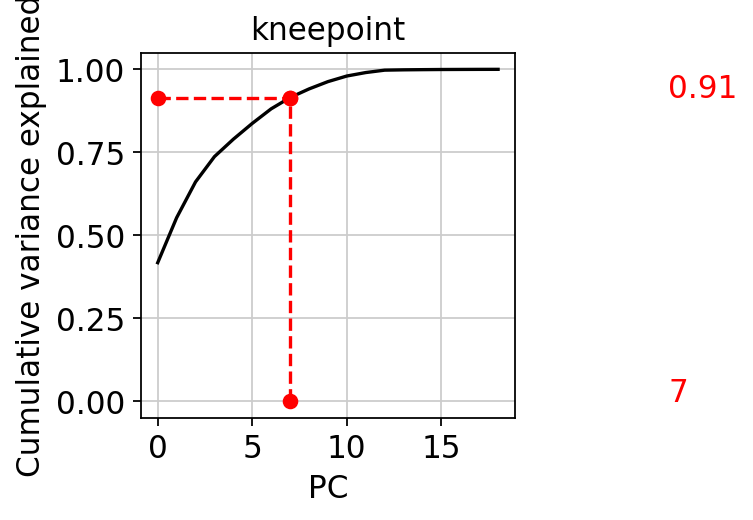

In [ ]:
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'kneepoint', min_pcs = 1)

In [ ]:
adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:selected_pcs].copy()

In [ ]:
distances, indices = knn_gpu(adata_sub.obsm['X_pca'])
adata_sub.obs['pheno_30'] = phenograph_gpu(indices)

In [ ]:
adata_sub.obs['pheno_30'] = pd.Categorical(adata_sub.obs['pheno_30'])

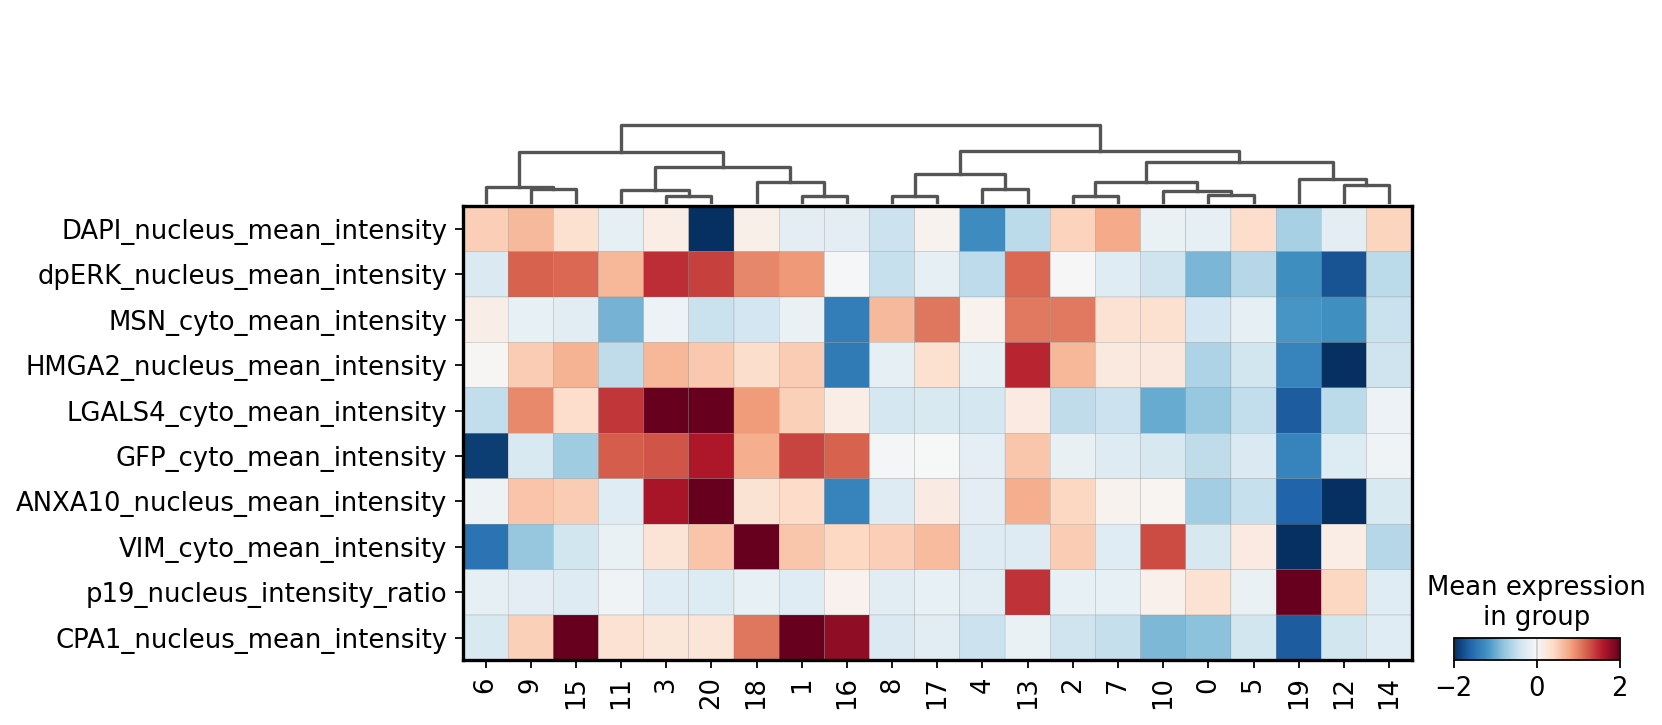

In [ ]:
sc.tl.dendrogram(adata_sub, groupby = 'pheno_30', var_names = valid_markers_reduced, linkage_method = "ward")
sc.pl.matrixplot(adata_sub, groupby = 'pheno_30', var_names = valid_markers_reduced, dendrogram=True, vmin = -2, vmax = 2, cmap='RdBu_r', swap_axes = True)

In [ ]:
adata_sub.obsm['X_spatial_2'] = adata_sub.obsm['X_spatial'][:,::-1].copy()
adata_sub.obsm['X_spatial_2'][:,1] = -adata_sub.obsm['X_spatial_2'][:,1]

#ax = plot_individual_category(adata_sub, "X_spatial_2", "pheno_30", [13], ["red", "navy", "gold", "limegreen"], figsize_max=10, use_outlines = True, frameon=True)

In [ ]:
adata_sub.obs['epithelial'] = pd.Categorical(ismember(adata_sub.obs['pheno_30'], [11,3,18,1,13])[1])

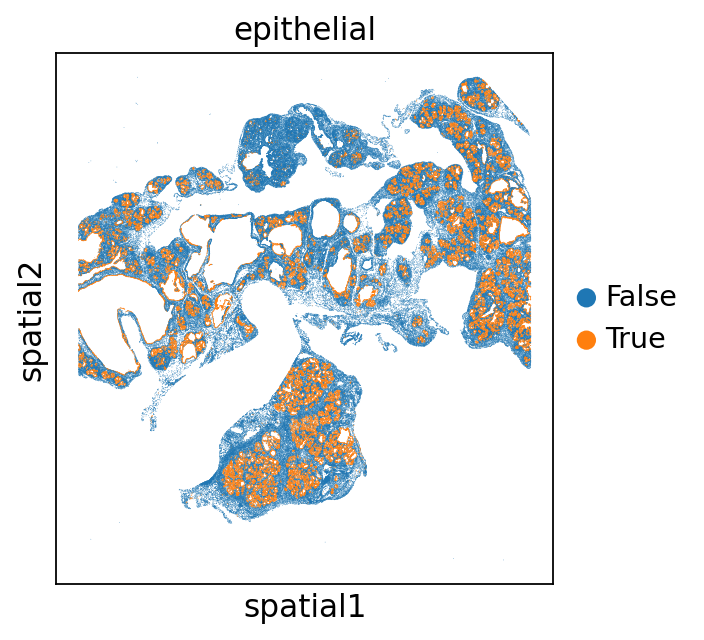

In [ ]:
sc.pl.scatter(adata_sub, color='epithelial', basis='spatial')

In [ ]:
adata_temp = query_region(adata_sub, "X_spatial_2", [10000,15000], [-21000, -16000])
adata_temp = adata_temp[adata_temp.obs['epithelial'] == True,:].copy()
#sc.pl.scatter(adata_temp, basis='spatial_2', color=['ANXA10_nucleus_mean_intensity', 'HMGA2_nucleus_mean_intensity', 'p19_nucleus_intensity_ratio', 'CPA1_nucleus_mean_intensity'])

### Write anndata

In [ ]:
output_dir = "../preprocessed"
os.makedirs(output_dir, exist_ok=True)
adata_temp = adata_sub[adata_sub.obs['epithelial'] == True,:].copy()
sc.write(os.path.join(output_dir, "Reyes_COMET_adata_epi_" + selected_slide + ".h5ad"), adata = adata_temp)

### Compute correlation matrix over all epithelial cells

In [ ]:
valid_markers = [
    'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity','ANXA10_cyto_mean_intensity',
    'p19_nucleus_intensity_ratio', 'CPA1_nucleus_mean_intensity']

In [ ]:
np.unique(adata_sub.obs['pheno_30'][adata_sub.obs['epithelial'] == True])

array([ 1,  3, 11, 13, 18])

In [ ]:
#adata_temp = adata_sub[adata_sub.obs['pheno_30'] == 1,:].copy()
adata_temp = adata_sub[adata_sub.obs['epithelial'] == True,:].copy()
adata_temp.X = adata_temp.layers['raw'].copy()
sc.pp.log1p(adata_temp)
sc.pp.scale(adata_temp)

In [ ]:
df = pd.DataFrame(np.array(adata_temp[:,valid_markers].X), columns = valid_markers)
corr = pd.DataFrame(np.corrcoef(df.T), index = valid_markers, columns = valid_markers)

In [ ]:
corr.shape

(6, 6)

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
linkage = linkage(corr.to_numpy(), method = "ward")
dendro = dendrogram(linkage, no_plot=True)
corr = corr.iloc[dendro['leaves'],:].iloc[:, dendro['leaves']]

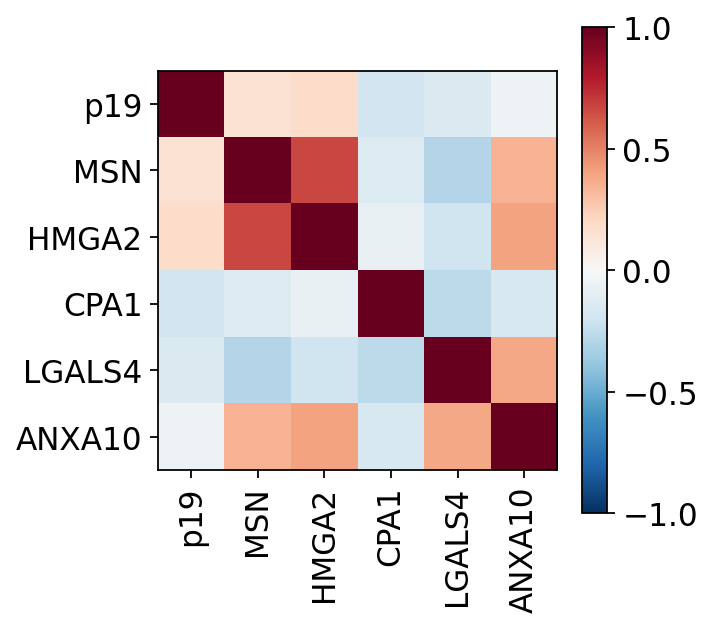

In [ ]:
im = plt.imshow(corr, vmin = -1, vmax = 1, cmap = 'RdBu_r')
my_labels = [re.findall('(\w+?)_', x)[0] for x in corr.index.to_numpy()]
h = plt.xticks(list(range(len(my_labels))), labels = my_labels, rotation = 90)
h = plt.yticks(list(range(len(my_labels))), labels = my_labels, rotation = 0)
plt.grid(False)
cbar = plt.colorbar()

### Compute correlation matrix after summarizing by phenograph cluster

In [ ]:
df = pd.DataFrame(np.array(adata_temp[:,valid_markers].X), columns = valid_markers)
df['pheno_30'] = adata_temp.obs['pheno_30'].to_numpy()
df_summarized = df.groupby('pheno_30').agg('mean')

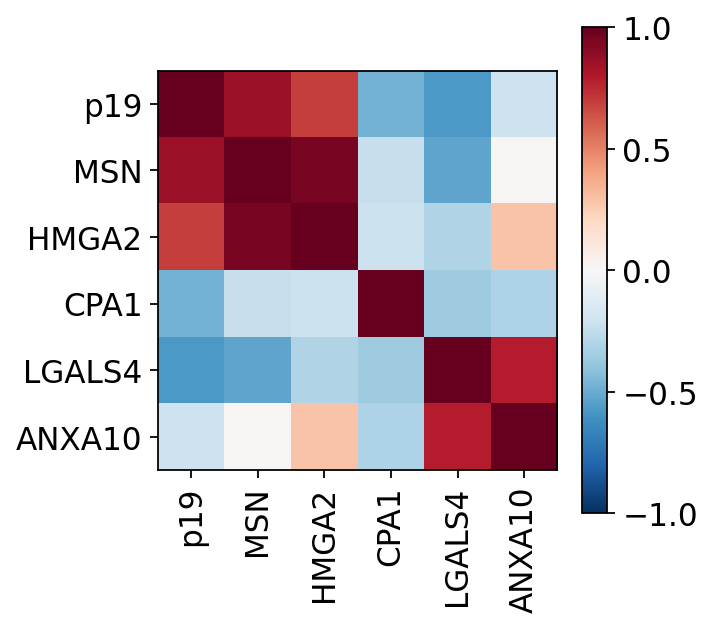

In [ ]:
corr = pd.DataFrame(np.corrcoef(df_summarized.T), index = df_summarized.columns, columns = df_summarized.columns)

from scipy.cluster.hierarchy import linkage, dendrogram
linkage = linkage(corr, method = "ward")
dendro = dendrogram(linkage, no_plot=True)

corr = pd.DataFrame(corr, index = valid_markers, columns = valid_markers)
corr = corr.iloc[dendro['leaves'],:].iloc[:, dendro['leaves']]

im = plt.imshow(corr, vmin = -1, vmax = 1, cmap = 'RdBu_r')
my_labels = [re.findall('(\w+?)_', x)[0] for x in corr.index.to_numpy()]
h = plt.xticks(list(range(len(my_labels))), labels = my_labels, rotation = 90)
h = plt.yticks(list(range(len(my_labels))), labels = my_labels, rotation = 0)
plt.grid(False)
cbar = plt.colorbar()